## 1. Install Dependencies and Font Setup

In [1]:
!pip install tensorflow-datasets -q
import subprocess
subprocess.run(['apt-get','install','-y','texlive-latex-extra','texlive-fonts-recommended','dvipng','cm-super'],capture_output=True)
import matplotlib
matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['font.serif']=['Computer Modern Roman']
matplotlib.rcParams['text.usetex']=False
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold
import seaborn as sns
import time
print('Libraries imported.')
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

Libraries imported.
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Load Oxford-IIIT Pet Dataset

In [2]:
IMG_SIZE=224
BATCH_SIZE=32
NUM_CLASSES=37
AUTOTUNE=tf.data.AUTOTUNE

def preprocess_sample(sample):
    image=tf.image.resize(sample['image'],[IMG_SIZE,IMG_SIZE])
    image=preprocess_input(tf.cast(image,tf.float32))
    label=tf.one_hot(sample['label'],NUM_CLASSES)
    return image,label

ds_train_raw,info=tfds.load('oxford_iiit_pet',split='train',with_info=True,as_supervised=False)
ds_test_raw=tfds.load('oxford_iiit_pet',split='test',as_supervised=False)
class_names=info.features['label'].names
n_train=info.splits['train'].num_examples
n_val=int(0.2*n_train)
n_tr=n_train-n_val

print(f'Classes : {NUM_CLASSES}')
print(f'Train   : {n_train}')
print(f'Test    : {info.splits["test"].num_examples}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1788102125.524071      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788102125.527343      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.K6H90L_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.K6H90L_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Classes : 37
Train   : 3680
Test    : 3669


## 3. Build tf.data Pipelines

In [3]:
ds_train=(ds_train_raw.map(preprocess_sample,num_parallel_calls=AUTOTUNE).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE))
ds_test=(ds_test_raw.map(preprocess_sample,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE))
ds_tr_study=(ds_train_raw.map(preprocess_sample,num_parallel_calls=AUTOTUNE).skip(n_val).batch(BATCH_SIZE).prefetch(AUTOTUNE))
ds_val_study=(ds_train_raw.map(preprocess_sample,num_parallel_calls=AUTOTUNE).take(n_val).batch(BATCH_SIZE).prefetch(AUTOTUNE))
print('Pipelines ready.')

Pipelines ready.


## 4. Sample Images and Class Distribution

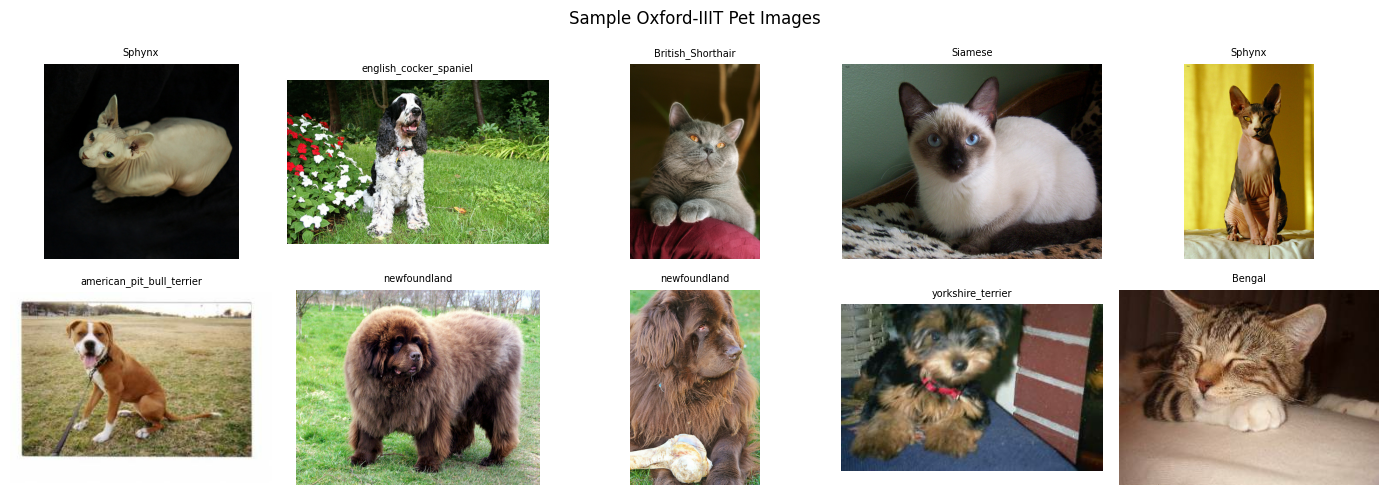

In [4]:
samples=list(ds_train_raw.take(10))
plt.figure(figsize=(14,5))
for i,s in enumerate(samples):
    plt.subplot(2,5,i+1)
    plt.imshow(s['image'].numpy())
    plt.title(class_names[s['label'].numpy()],fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Oxford-IIIT Pet Images',fontsize=12)
plt.tight_layout()
plt.savefig('sample_images.png',dpi=600,bbox_inches='tight')
plt.show()

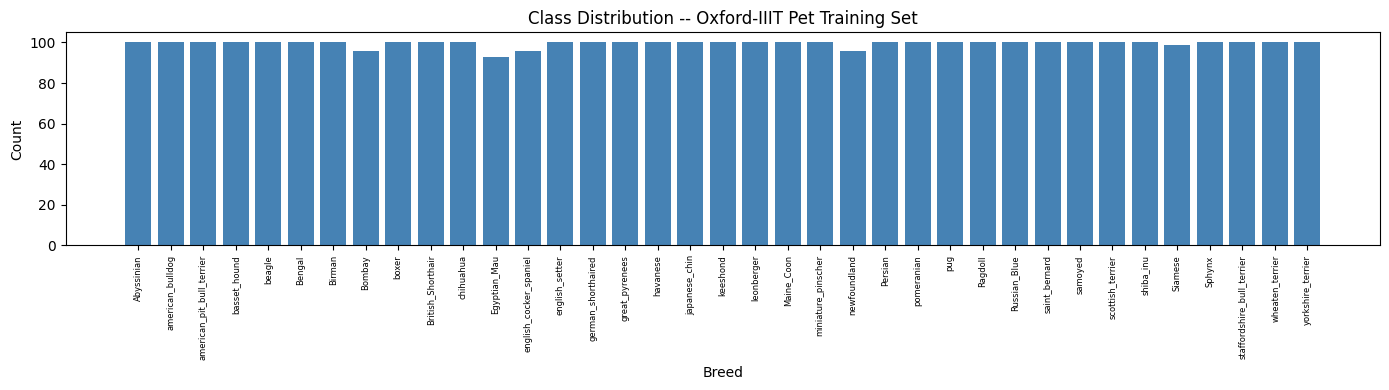

In [5]:
label_counts=np.zeros(NUM_CLASSES,dtype=int)
for s in ds_train_raw:
    label_counts[s['label'].numpy()]+=1
plt.figure(figsize=(14,4))
plt.bar(range(NUM_CLASSES),label_counts,color='steelblue')
plt.xticks(range(NUM_CLASSES),class_names,rotation=90,fontsize=6)
plt.title('Class Distribution -- Oxford-IIIT Pet Training Set')
plt.xlabel('Breed')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png',dpi=600,bbox_inches='tight')
plt.show()

## 5. Helper -- build_model()

In [6]:
def build_model(dropout_rate=0.3,l2_reg=0.0,use_bn=True,
                kernel_init='he_normal',dense_units=256,frozen=True):
    base=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
    base.trainable=not frozen
    inp=tf.keras.Input(shape=(224,224,3))
    x=base(inp,training=False)
    x=layers.GlobalAveragePooling2D()(x)
    if use_bn:
        x=layers.BatchNormalization()(x)
    reg=regularizers.l2(l2_reg) if l2_reg>0 else None
    x=layers.Dense(dense_units,activation='relu',kernel_initializer=kernel_init,kernel_regularizer=reg)(x)
    if dropout_rate>0:
        x=layers.Dropout(dropout_rate)(x)
    out=layers.Dense(NUM_CLASSES,activation='softmax')(x)
    return tf.keras.Model(inp,out)
print('build_model() defined.')

build_model() defined.


## 6. Study 1 -- Weight Initialization (Plots 1 and 2)

In [7]:
EPOCHS_STUDY=5
init_methods={'Zeros':'zeros','Random Normal':'random_normal','Xavier (Glorot)':'glorot_uniform','He Normal':'he_normal'}
init_histories={}
for name,init in init_methods.items():
    print(f'Training with {name} ...')
    m=build_model(kernel_init=init)
    m.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
    h=m.fit(ds_tr_study,validation_data=ds_val_study,epochs=EPOCHS_STUDY,verbose=0)
    init_histories[name]=h
    print(f'  Val acc: {h.history["val_accuracy"][-1]:.4f}')

Training with Zeros ...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-08-30 15:02:44.071122: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 15:02:44.208145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788102166.722305     164 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Val acc: 0.0136
Training with Random Normal ...
  Val acc: 0.9076
Training with Xavier (Glorot) ...
  Val acc: 0.9144
Training with He Normal ...
  Val acc: 0.9076


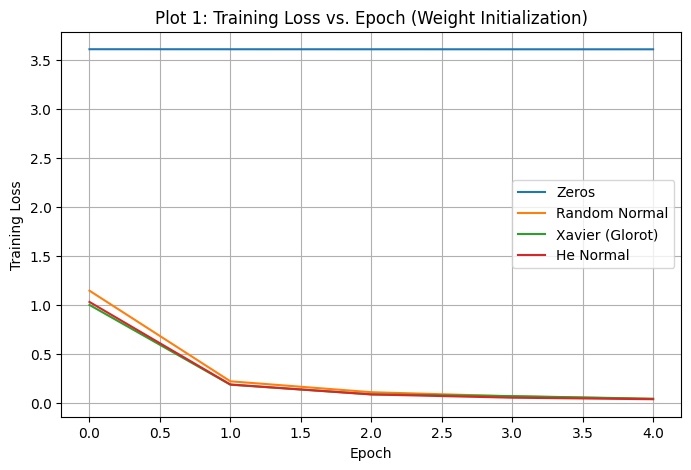

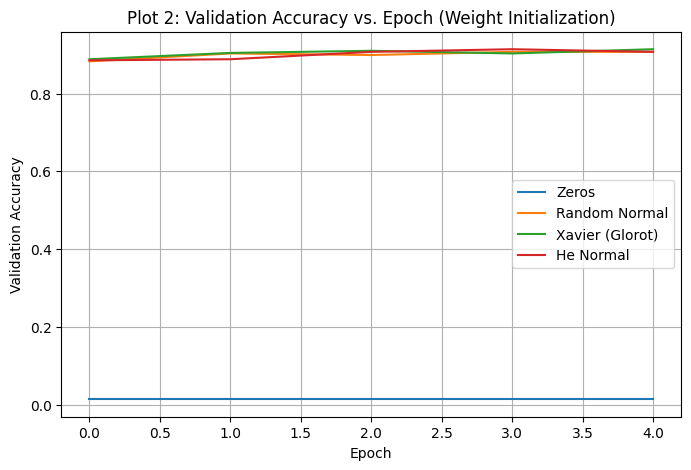

Plots 1 and 2 saved.


In [8]:
plt.figure(figsize=(8,5))
for name,h in init_histories.items():
    plt.plot(h.history['loss'],label=name)
plt.title('Plot 1: Training Loss vs. Epoch (Weight Initialization)')
plt.xlabel('Epoch');plt.ylabel('Training Loss');plt.legend();plt.grid(True)
plt.savefig('plot1_init_loss.png',dpi=600,bbox_inches='tight');plt.show()

plt.figure(figsize=(8,5))
for name,h in init_histories.items():
    plt.plot(h.history['val_accuracy'],label=name)
plt.title('Plot 2: Validation Accuracy vs. Epoch (Weight Initialization)')
plt.xlabel('Epoch');plt.ylabel('Validation Accuracy');plt.legend();plt.grid(True)
plt.savefig('plot2_init_valacc.png',dpi=600,bbox_inches='tight');plt.show()
print('Plots 1 and 2 saved.')

## 7. Study 2 -- Regularization (Plots 3 and 4)

In [9]:
reg_configs={'No Reg':dict(dropout_rate=0.0,l2_reg=0.0,use_bn=False),'L2':dict(dropout_rate=0.0,l2_reg=1e-4,use_bn=False),'Dropout 0.5':dict(dropout_rate=0.5,l2_reg=0.0,use_bn=False),'Batch Norm':dict(dropout_rate=0.0,l2_reg=0.0,use_bn=True)}
reg_histories={}
for name,cfg in reg_configs.items():
    print(f'Training: {name} ...')
    m=build_model(**cfg)
    m.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
    h=m.fit(ds_tr_study,validation_data=ds_val_study,epochs=EPOCHS_STUDY,verbose=0)
    reg_histories[name]=h
    print(f'  Val acc: {h.history["val_accuracy"][-1]:.4f}')

Training: No Reg ...
  Val acc: 0.9076
Training: L2 ...
  Val acc: 0.9158
Training: Dropout 0.5 ...
  Val acc: 0.9103
Training: Batch Norm ...
  Val acc: 0.9185


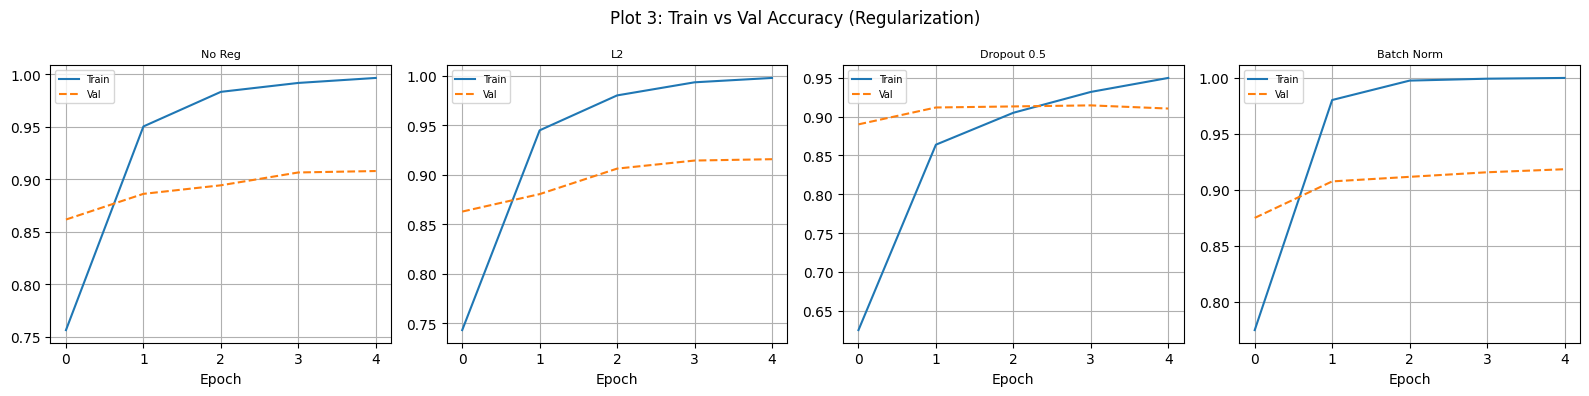

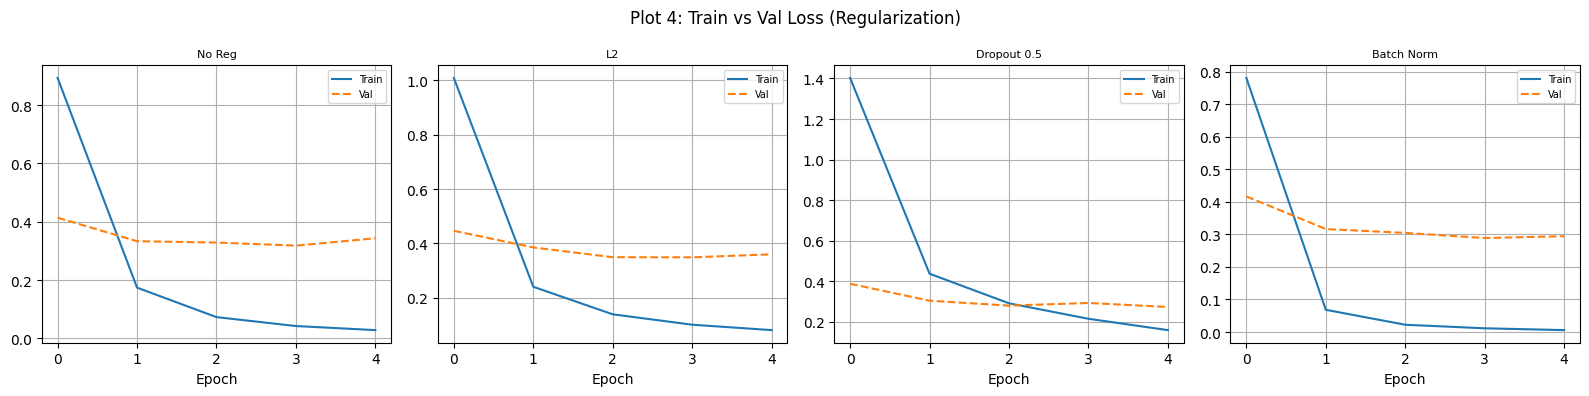

Plots 3 and 4 saved.


In [10]:
fig,axes=plt.subplots(1,4,figsize=(16,4))
for ax,(name,h) in zip(axes,reg_histories.items()):
    ax.plot(h.history['accuracy'],label='Train');ax.plot(h.history['val_accuracy'],label='Val',linestyle='--')
    ax.set_title(name,fontsize=8);ax.set_xlabel('Epoch');ax.legend(fontsize=7);ax.grid(True)
plt.suptitle('Plot 3: Train vs Val Accuracy (Regularization)');plt.tight_layout()
plt.savefig('plot3_reg_accuracy.png',dpi=600,bbox_inches='tight');plt.show()

fig,axes=plt.subplots(1,4,figsize=(16,4))
for ax,(name,h) in zip(axes,reg_histories.items()):
    ax.plot(h.history['loss'],label='Train');ax.plot(h.history['val_loss'],label='Val',linestyle='--')
    ax.set_title(name,fontsize=8);ax.set_xlabel('Epoch');ax.legend(fontsize=7);ax.grid(True)
plt.suptitle('Plot 4: Train vs Val Loss (Regularization)');plt.tight_layout()
plt.savefig('plot4_reg_loss.png',dpi=600,bbox_inches='tight');plt.show()
print('Plots 3 and 4 saved.')

## 8. Study 3 -- Batch Normalization (Plot 5)

Without BN ...
With BN ...


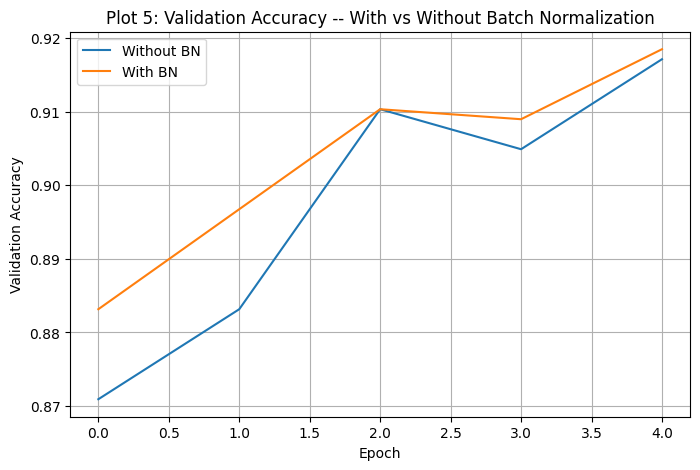

Plot 5 saved.


In [11]:
bn_configs={'Without BN':dict(use_bn=False,dropout_rate=0.3),'With BN':dict(use_bn=True,dropout_rate=0.3)}
bn_histories={}
for name,cfg in bn_configs.items():
    print(f'{name} ...')
    m=build_model(**cfg)
    m.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
    h=m.fit(ds_tr_study,validation_data=ds_val_study,epochs=EPOCHS_STUDY,verbose=0)
    bn_histories[name]=h
plt.figure(figsize=(8,5))
for name,h in bn_histories.items():
    plt.plot(h.history['val_accuracy'],label=name)
plt.title('Plot 5: Validation Accuracy -- With vs Without Batch Normalization')
plt.xlabel('Epoch');plt.ylabel('Validation Accuracy');plt.legend();plt.grid(True)
plt.savefig('plot5_batchnorm.png',dpi=600,bbox_inches='tight');plt.show()
print('Plot 5 saved.')

## 9. Study 4 -- Optimizers (Plots 6 and 7)

In [12]:
optimizers={'SGD':SGD(0.001),'Momentum':SGD(0.001,momentum=0.9),'RMSProp':RMSprop(0.001),'Adam':Adam(0.001)}
opt_histories={};opt_times={}
for name,opt in optimizers.items():
    print(f'Training with {name} ...')
    m=build_model(dropout_rate=0.3,use_bn=True)
    m.compile(optimizer=opt,loss='categorical_crossentropy',metrics=['accuracy'])
    start=time.time()
    h=m.fit(ds_tr_study,validation_data=ds_val_study,epochs=EPOCHS_STUDY,verbose=0)
    opt_times[name]=time.time()-start;opt_histories[name]=h
    print(f'  Val acc: {h.history["val_accuracy"][-1]:.4f}  Time: {opt_times[name]:.1f}s')

Training with SGD ...
  Val acc: 0.5530  Time: 43.4s
Training with Momentum ...
  Val acc: 0.8981  Time: 45.3s
Training with RMSProp ...
  Val acc: 0.9076  Time: 44.4s
Training with Adam ...
  Val acc: 0.9130  Time: 47.2s


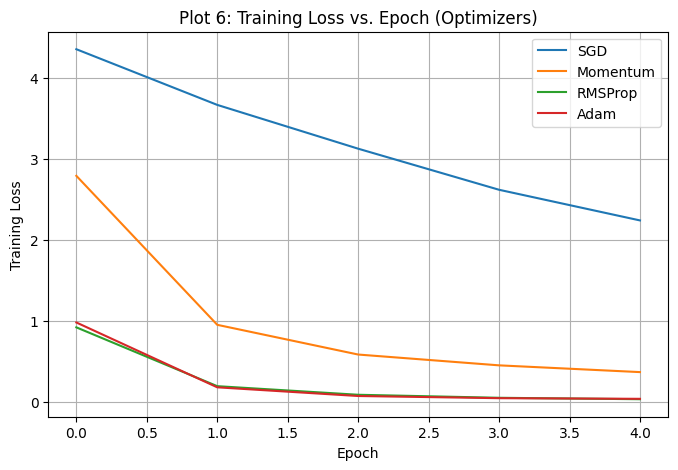

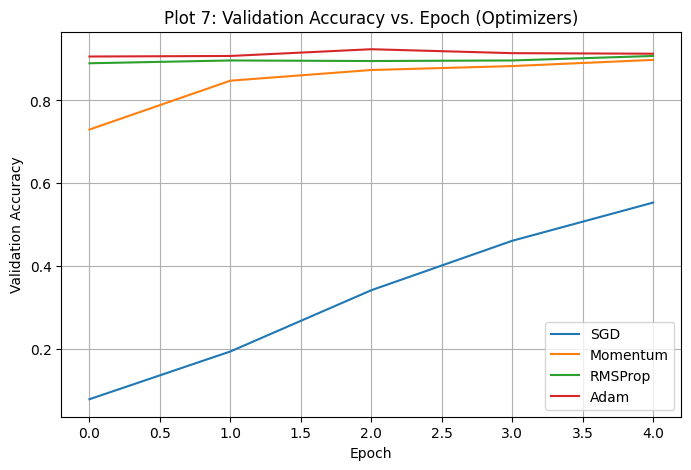

Plots 6 and 7 saved.

Optimizer Summary:
  SGD        Loss:2.2451 ValAcc:0.5530 Time:43.4s
  Momentum   Loss:0.3714 ValAcc:0.8981 Time:45.3s
  RMSProp    Loss:0.0364 ValAcc:0.9076 Time:44.4s
  Adam       Loss:0.0413 ValAcc:0.9130 Time:47.2s


In [13]:
plt.figure(figsize=(8,5))
for name,h in opt_histories.items():
    plt.plot(h.history['loss'],label=name)
plt.title('Plot 6: Training Loss vs. Epoch (Optimizers)')
plt.xlabel('Epoch');plt.ylabel('Training Loss');plt.legend();plt.grid(True)
plt.savefig('plot6_opt_loss.png',dpi=600,bbox_inches='tight');plt.show()

plt.figure(figsize=(8,5))
for name,h in opt_histories.items():
    plt.plot(h.history['val_accuracy'],label=name)
plt.title('Plot 7: Validation Accuracy vs. Epoch (Optimizers)')
plt.xlabel('Epoch');plt.ylabel('Validation Accuracy');plt.legend();plt.grid(True)
plt.savefig('plot7_opt_valacc.png',dpi=600,bbox_inches='tight');plt.show()
print('Plots 6 and 7 saved.')
print('\nOptimizer Summary:')
for name,h in opt_histories.items():
    print(f'  {name:10s} Loss:{h.history["loss"][-1]:.4f} ValAcc:{h.history["val_accuracy"][-1]:.4f} Time:{opt_times[name]:.1f}s')

## 10. Study 5 -- Hyperparameter Tuning (Plots 8, 9, 10)

LR=0.01 ...
  Val acc: 0.8560
LR=0.001 ...
  Val acc: 0.9144
LR=0.0001 ...
  Val acc: 0.8886
LR=1e-05 ...


  Val acc: 0.2568


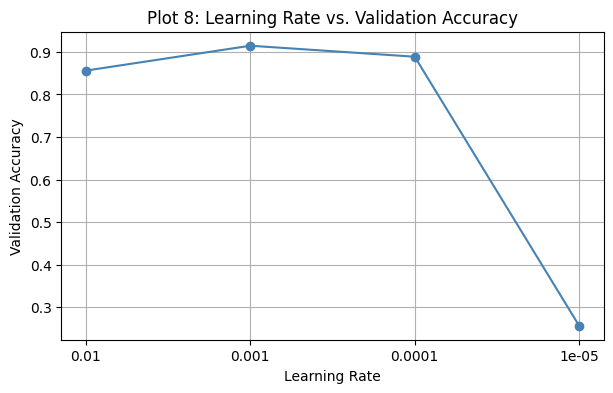

In [14]:
# Plot 8 -- Learning Rate
lrs=[0.01,0.001,0.0001,0.00001];lr_accs=[]
for lr in lrs:
    print(f'LR={lr} ...')
    m=build_model(dropout_rate=0.3,use_bn=True)
    m.compile(optimizer=Adam(lr),loss='categorical_crossentropy',metrics=['accuracy'])
    h=m.fit(ds_tr_study,validation_data=ds_val_study,epochs=EPOCHS_STUDY,verbose=0)
    lr_accs.append(h.history['val_accuracy'][-1])
    print(f'  Val acc: {lr_accs[-1]:.4f}')
plt.figure(figsize=(7,4))
plt.plot([str(lr) for lr in lrs],lr_accs,marker='o',color='steelblue')
plt.title('Plot 8: Learning Rate vs. Validation Accuracy')
plt.xlabel('Learning Rate');plt.ylabel('Validation Accuracy');plt.grid(True)
plt.savefig('plot8_lr.png',dpi=600,bbox_inches='tight');plt.show()

Batch size=16 ...


2026-08-30 15:16:54.488623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 15:16:54.625790: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Val acc: 0.9103
Batch size=32 ...
  Val acc: 0.9130
Batch size=64 ...


2026-08-30 15:18:40.818553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 15:18:40.958407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Val acc: 0.9090


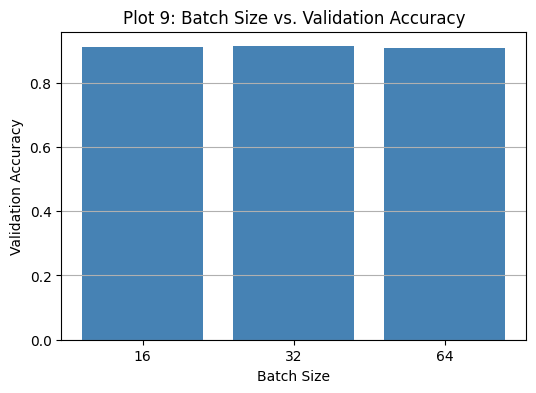

In [15]:
# Plot 9 -- Batch Size
batch_sizes=[16,32,64];bs_accs=[]
for bs in batch_sizes:
    print(f'Batch size={bs} ...')
    ds_tr_bs=(ds_train_raw.map(preprocess_sample,num_parallel_calls=AUTOTUNE).skip(n_val).batch(bs).prefetch(AUTOTUNE))
    ds_val_bs=(ds_train_raw.map(preprocess_sample,num_parallel_calls=AUTOTUNE).take(n_val).batch(bs).prefetch(AUTOTUNE))
    m=build_model(dropout_rate=0.3,use_bn=True)
    m.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
    h=m.fit(ds_tr_bs,validation_data=ds_val_bs,epochs=EPOCHS_STUDY,verbose=0)
    bs_accs.append(h.history['val_accuracy'][-1])
    print(f'  Val acc: {bs_accs[-1]:.4f}')
plt.figure(figsize=(6,4))
plt.bar([str(b) for b in batch_sizes],bs_accs,color='steelblue')
plt.title('Plot 9: Batch Size vs. Validation Accuracy')
plt.xlabel('Batch Size');plt.ylabel('Validation Accuracy');plt.grid(axis='y')
plt.savefig('plot9_batchsize.png',dpi=600,bbox_inches='tight');plt.show()

Dropout=0.0 ...
  Val acc: 0.8995
Dropout=0.25 ...
  Val acc: 0.9103
Dropout=0.5 ...


  Val acc: 0.9198


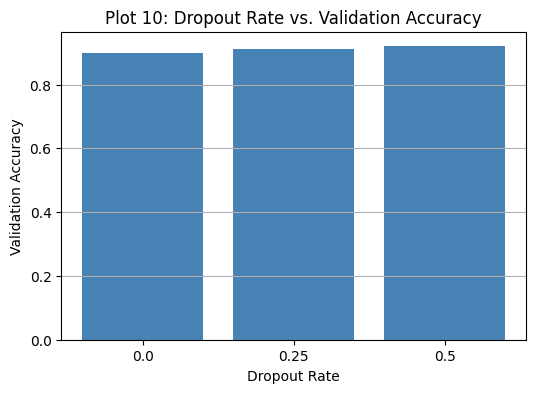

Plots 8, 9, 10 saved.


In [16]:
# Plot 10 -- Dropout Rate
dropout_rates=[0.0,0.25,0.5];dr_accs=[]
for dr in dropout_rates:
    print(f'Dropout={dr} ...')
    m=build_model(dropout_rate=dr,use_bn=True)
    m.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
    h=m.fit(ds_tr_study,validation_data=ds_val_study,epochs=EPOCHS_STUDY,verbose=0)
    dr_accs.append(h.history['val_accuracy'][-1])
    print(f'  Val acc: {dr_accs[-1]:.4f}')
plt.figure(figsize=(6,4))
plt.bar([str(d) for d in dropout_rates],dr_accs,color='steelblue')
plt.title('Plot 10: Dropout Rate vs. Validation Accuracy')
plt.xlabel('Dropout Rate');plt.ylabel('Validation Accuracy');plt.grid(axis='y')
plt.savefig('plot10_dropout.png',dpi=600,bbox_inches='tight');plt.show()
print('Plots 8, 9, 10 saved.')

## 11. Study 6 -- Feature Extraction vs Fine Tuning (Plots 11 and 12)

In [17]:
# Feature Extraction
print('Feature Extraction ...')
model_fe=build_model(dropout_rate=0.3,use_bn=True,frozen=True)
model_fe.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
h_fe=model_fe.fit(ds_tr_study,validation_data=ds_val_study,epochs=10,verbose=1)

# Fine Tuning
print('Fine Tuning ...')
model_ft=build_model(dropout_rate=0.3,use_bn=True,frozen=True)
model_ft.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
model_ft.fit(ds_tr_study,validation_data=ds_val_study,epochs=5,verbose=0)
# Unfreeze last 20 layers
base_ft=model_ft.layers[1]
base_ft.trainable=True
for layer in base_ft.layers[:-20]:
    layer.trainable=False
model_ft.compile(optimizer=Adam(0.0001),loss='categorical_crossentropy',metrics=['accuracy'])
h_ft=model_ft.fit(ds_tr_study,validation_data=ds_val_study,epochs=10,verbose=1)
print('Transfer learning study complete.')

Feature Extraction ...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.7221 - loss: 0.9981 - val_accuracy: 0.8791 - val_loss: 0.3955
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9416 - loss: 0.1774 - val_accuracy: 0.9076 - val_loss: 0.3026
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9721 - loss: 0.0900 - val_accuracy: 0.9008 - val_loss: 0.3104
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9796 - loss: 0.0653 - val_accuracy: 0.9090 - val_loss: 0.2996
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9874 - loss: 0.0427 - val_accuracy: 0.9090 - val_loss: 0.3233
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9946 - loss: 0.0258 - val_accuracy: 0.9158 - val_loss: 0.3174
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9969 - loss: 0.0167 - val_accuracy: 0.9144 - val_loss: 0.3145
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9973 - loss: 0.0137 -

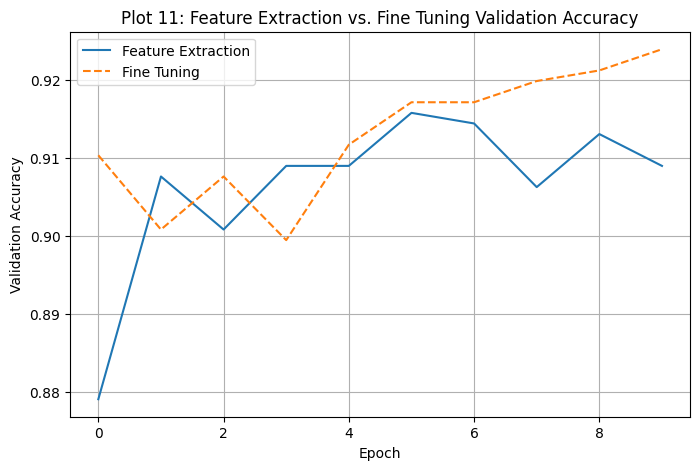

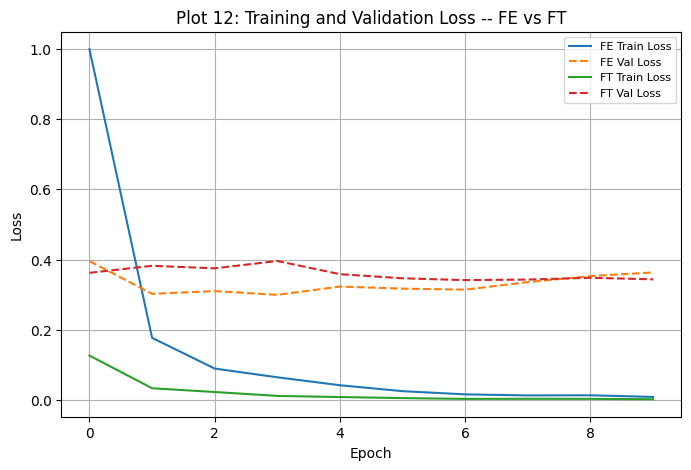

Plots 11 and 12 saved.


In [18]:
plt.figure(figsize=(8,5))
plt.plot(h_fe.history['val_accuracy'],label='Feature Extraction')
plt.plot(h_ft.history['val_accuracy'],label='Fine Tuning',linestyle='--')
plt.title('Plot 11: Feature Extraction vs. Fine Tuning Validation Accuracy')
plt.xlabel('Epoch');plt.ylabel('Validation Accuracy');plt.legend();plt.grid(True)
plt.savefig('plot11_fe_vs_ft.png',dpi=600,bbox_inches='tight');plt.show()

plt.figure(figsize=(8,5))
plt.plot(h_fe.history['loss'],label='FE Train Loss')
plt.plot(h_fe.history['val_loss'],label='FE Val Loss',linestyle='--')
plt.plot(h_ft.history['loss'],label='FT Train Loss')
plt.plot(h_ft.history['val_loss'],label='FT Val Loss',linestyle='--')
plt.title('Plot 12: Training and Validation Loss -- FE vs FT')
plt.xlabel('Epoch');plt.ylabel('Loss');plt.legend(fontsize=8);plt.grid(True)
plt.savefig('plot12_fe_ft_loss.png',dpi=600,bbox_inches='tight');plt.show()
print('Plots 11 and 12 saved.')

## 12. 5-Fold Cross-Validation (Plot 13)

In [19]:
print('Collecting training data for CV ...')
X_all,y_all=[],[]
for img,lbl in ds_train_raw.map(preprocess_sample).batch(64).prefetch(AUTOTUNE):
    X_all.append(img.numpy());y_all.append(lbl.numpy())
X_all=np.concatenate(X_all);y_all=np.concatenate(y_all)
print(f'X_all: {X_all.shape}')

configs={'C1 Baseline':dict(dropout_rate=0.0,use_bn=False,l2_reg=0.0),
         'C2 Dropout+BN':dict(dropout_rate=0.3,use_bn=True,l2_reg=0.0),
         'C3 L2+BN':dict(dropout_rate=0.0,use_bn=True,l2_reg=1e-4),
         'C4 All':dict(dropout_rate=0.3,use_bn=True,l2_reg=1e-4)}

kf=KFold(n_splits=5,shuffle=True,random_state=42)
cv_results={name:[] for name in configs}

for cfg_name,cfg in configs.items():
    print(f'CV for {cfg_name} ...')
    for fold,(tr_idx,val_idx) in enumerate(kf.split(X_all)):
        print(f'  Fold {fold+1}/5 ...')
        m=build_model(**cfg)
        m.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
        m.fit(X_all[tr_idx],y_all[tr_idx],validation_data=(X_all[val_idx],y_all[val_idx]),epochs=3,batch_size=32,verbose=0)
        _,acc=m.evaluate(X_all[val_idx],y_all[val_idx],verbose=0)
        cv_results[cfg_name].append(acc)
        print(f'    acc={acc:.4f}')

print('CV Results:')
for name,accs in cv_results.items():
    print(f'  {name}: {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

X_all: (3680, 224, 224, 3)
CV for C1 Baseline ...
  Fold 1/5 ...
    acc=0.8927
  Fold 2/5 ...
    acc=0.8818
  Fold 3/5 ...
    acc=0.8981
  Fold 4/5 ...
    acc=0.9090
  Fold 5/5 ...
    acc=0.9117
CV for C2 Dropout+BN ...
  Fold 1/5 ...
    acc=0.9103
  Fold 2/5 ...
    acc=0.8981
  Fold 3/5 ...
    acc=0.8927
  Fold 4/5 ...
    acc=0.9158
  Fold 5/5 ...
    acc=0.9144
CV for C3 L2+BN ...
  Fold 1/5 ...
    acc=0.9117
  Fold 2/5 ...
    acc=0.9103
  Fold 3/5 ...
    acc=0.8913
  Fold 4/5 ...
    acc=0.9062
  Fold 5/5 ...
    acc=0.9130
CV for C4 All ...
  Fold 1/5 ...
    acc=0.8913
  Fold 2/5 ...
    acc=0.9117
  Fold 3/5 ...
    acc=0.9062
  Fold 4/5 ...
    acc=0.9076
  Fold 5/5 ...
    acc=0.8981
CV Results:
  C1 Baseline: 0.8986 +/- 0.0109
  C2 Dropout+BN: 0.9062 +/- 0.0092
  C3 L2+BN: 0.9065 +/- 0.0079
  C4 All: 0.9030 +/- 0.0073


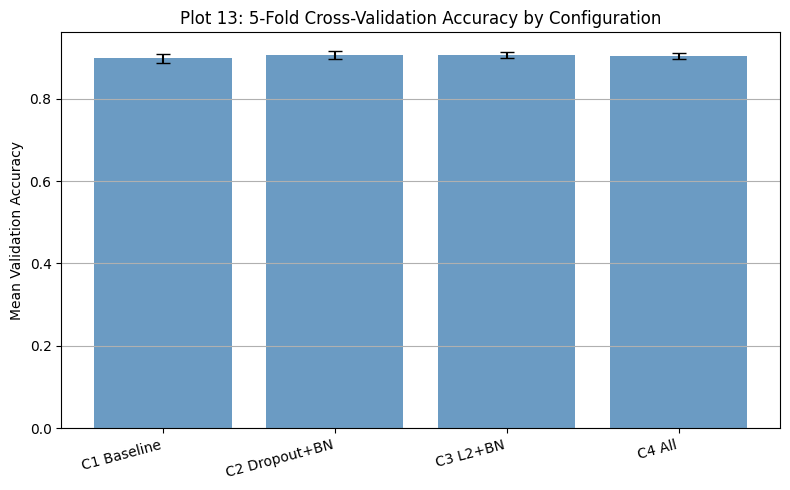

Plot 13 saved.


In [20]:
means=[np.mean(cv_results[n]) for n in configs]
stds=[np.std(cv_results[n]) for n in configs]
plt.figure(figsize=(8,5))
plt.bar(range(len(configs)),means,yerr=stds,capsize=5,color='steelblue',alpha=0.8)
plt.xticks(range(len(configs)),list(configs.keys()),rotation=15,ha='right')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy by Configuration')
plt.ylabel('Mean Validation Accuracy');plt.grid(axis='y');plt.tight_layout()
plt.savefig('plot13_cv.png',dpi=600,bbox_inches='tight');plt.show()
print('Plot 13 saved.')

## 13. Final Model Evaluation (Plots 14 and 15)

In [21]:
best_cfg_name=max(cv_results,key=lambda n:np.mean(cv_results[n]))
best_cfg=configs[best_cfg_name]
print(f'Best config: {best_cfg_name}')
print(f'CV Mean: {np.mean(cv_results[best_cfg_name]):.4f}')
print(f'CV SD  : {np.std(cv_results[best_cfg_name]):.4f}')

print('Retraining on full training set ...')
final_model=build_model(**best_cfg)
final_model.compile(optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
start=time.time()
h_final=final_model.fit(ds_train,validation_data=ds_test,epochs=10,verbose=1)
train_time=time.time()-start
print(f'Training time: {train_time:.1f}s')

Best config: C3 L2+BN
CV Mean: 0.9065
CV SD  : 0.0079
Retraining on full training set ...
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6564 - loss: 1.3532

2026-08-30 15:36:56.210160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 15:36:56.365873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 15:36:56.502837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


115/115 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - accuracy: 0.8003 - loss: 0.7406 - val_accuracy: 0.8749 - val_loss: 0.4681
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.9647 - loss: 0.1612 - val_accuracy: 0.8880 - val_loss: 0.4178
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.9891 - loss: 0.0996 - val_accuracy: 0.8844 - val_loss: 0.4595
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9943 - loss: 0.0815 - val_accuracy: 0.8902 - val_loss: 0.4510
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.9965 - loss: 0.0751 - val_accuracy: 0.8956 - val_loss: 0.4515
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.9992 - loss: 0.0639 - val_accuracy: 0.8956 - val_loss: 0.4610
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9995 - loss: 0.0603 - val_accuracy: 0.8951 - val_loss: 0.4648
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 1.0000 - loss: 0.0575 - val_accura

Classification Report:
                            precision    recall  f1-score   support

                Abyssinian       0.82      0.93      0.87        98
          american_bulldog       0.72      0.89      0.79       100
 american_pit_bull_terrier       0.81      0.59      0.68       100
              basset_hound       0.95      0.91      0.93       100
                    beagle       0.89      0.92      0.91       100
                    Bengal       0.79      0.90      0.84       100
                    Birman       0.78      0.82      0.80       100
                    Bombay       0.86      0.93      0.90        88
                     boxer       0.88      0.92      0.90        99
         British_Shorthair       0.86      0.77      0.81       100
                 chihuahua       0.92      0.85      0.89       100
              Egyptian_Mau       0.91      0.86      0.88        97
    english_cocker_spaniel       0.95      0.96      0.96       100
            english_sett

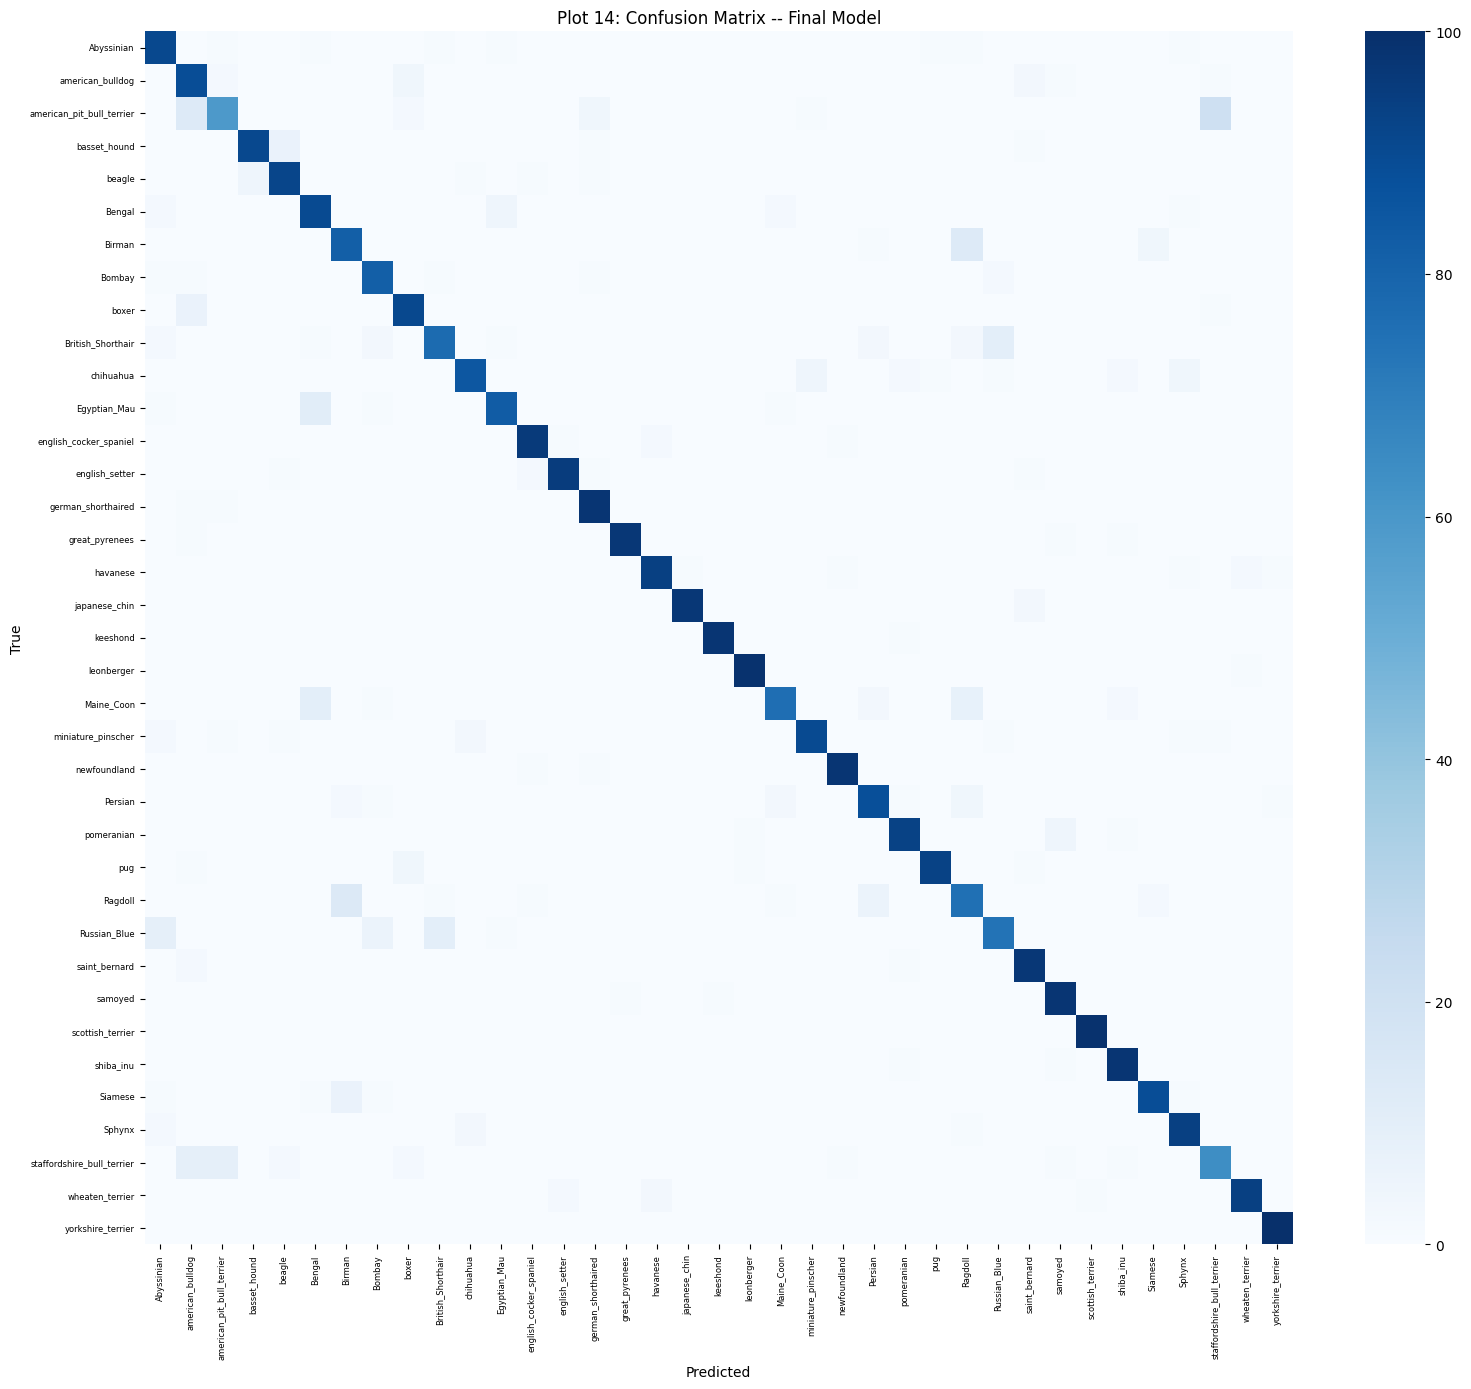

In [22]:
y_true_list,y_pred_list=[],[]
for X_batch,y_batch in ds_test:
    preds=final_model.predict(X_batch,verbose=0)
    y_pred_list.extend(np.argmax(preds,axis=1))
    y_true_list.extend(np.argmax(y_batch.numpy(),axis=1))
y_true_f=np.array(y_true_list);y_pred_f=np.array(y_pred_list)
print('Classification Report:')
print(classification_report(y_true_f,y_pred_f,target_names=class_names))

cm=confusion_matrix(y_true_f,y_pred_f)
plt.figure(figsize=(16,14))
sns.heatmap(cm,annot=False,cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.title('Plot 14: Confusion Matrix -- Final Model')
plt.xlabel('Predicted');plt.ylabel('True')
plt.xticks(rotation=90,fontsize=6);plt.yticks(rotation=0,fontsize=6)
plt.tight_layout()
plt.savefig('plot14_confusion_matrix.png',dpi=600,bbox_inches='tight');plt.show()

In [23]:
X_disp,y_disp=[],[]
for s in ds_test_raw.take(500):
    X_disp.append(s['image'].numpy());y_disp.append(s['label'].numpy())
X_disp=np.array(X_disp);y_disp=np.array(y_disp)
X_proc=preprocess_input(tf.image.resize(X_disp.astype('float32'),[224,224]).numpy())
preds_disp=np.argmax(final_model.predict(X_proc,verbose=0),axis=1)
wrong=np.where(preds_disp!=y_disp)[0][:8]
plt.figure(figsize=(14,6))
for i,idx in enumerate(wrong):
    plt.subplot(2,4,i+1)
    plt.imshow(X_disp[idx])
    plt.title(f'True:{class_names[y_disp[idx]]}\nPred:{class_names[preds_disp[idx]]}',fontsize=7)
    plt.axis('off')
plt.suptitle('Plot 15: Misclassified Test Images',fontsize=12);plt.tight_layout()
plt.savefig('plot15_misclassified.png',dpi=600,bbox_inches='tight');plt.show()
print('Plots 14 and 15 saved.')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (500,) + inhomogeneous part.

In [ ]:
loss_f,acc_f=final_model.evaluate(ds_test,verbose=0)
print('='*55)
print('FINAL RESULTS SUMMARY')
print('='*55)
print(f'Best Config         : {best_cfg_name}')
print(f'CV Mean Accuracy    : {np.mean(cv_results[best_cfg_name])*100:.2f}%')
print(f'CV Std Dev          : {np.std(cv_results[best_cfg_name])*100:.2f}%')
print(f'Test Accuracy       : {acc_f*100:.2f}%')
print(f'Test Loss           : {loss_f:.4f}')
print(f'Total Train Time    : {train_time:.1f}s')
print(f'Total Parameters    : {final_model.count_params():,}')